# NIBLEs Tutorial Part 3: Advanced Sample Creation

In preparation for imaging experiments, we need to generate new samples that map our sample in space.

For this, we will generate 2 new samples: one of a square of uniform material, and one representing the human brain.

We'll begin by importing the relevant tools:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import NIBLEs.samplegen as sampgen
import NIBLEs.materials as matlib

We will begin with the square sample. Using the same steps followed in Part 1, please define a 10x10x1 cm imaging volume, divided into 64x64x1 pixels. Additionally, please create a `Material` instance, with the same relaxation properties as the material used in Part 1. 

We have provided a name for the sample. Furthermore, for these imaging experiments we will be assigning 12 magnetization vectors to each voxel (for the rationale behind this, please see the NIBLEs paper).

**Note:** For samples used in imaging experiments, the resolution defined at this step defines the highest possible resolution of any imaging simulation. Attempting to simulate higher-resolution images will create garbled images with unrealistic geometry and relaxation behaviours due to how magnetization vectors are arranged within a sample. Imaging at resolutions lower than that of your sample will still produce true-to-life results. For this tutorial, we are sticking with low-resolution images to keep simulation times to a minimum. In general, we recommend creating NIBLEs samples at the resolution of your planned imaging simulations to ensure accurate simulation while minimizing simulation times. 

In [ ]:
# Define volume dimensions


# Create a material


# Define the number of vectors per voxel


# Sample name and path


Now, we must create our spatial map. In this case, we will be using built in functions to draw our square within the imaging volume. Please create an instance of `ImagingVolume` named `Volume`.

As stated in Part 1, when we create an instance of `ImagingVolume` we create a zero-filled array with the given dimensions with the name `ImagingVolume.sample_mask`. Here, we will use the built in function `generate_square` to add a square object into `ImagingVolume.sample_mask`.

`generate_square` requires the following inputs:
* `dim` - The 3D dimensions of the square itself (yes, you can make a rectangular square)
* `mat_index` - The index number of the material composing the shape
* `cent` - The centerpoint of the square, given by the index of the voxel you want to be the centerpoint. If not specified, `generate_square` will place the shape at the center of the imaging volume.

Please use `generate_square` to create a square of your chosen dimensions wherever you wish within the imaging volume. Please ensure there are at least 2 empty voxels between the edge of your square and the edge of the imaging volume. We have included some plotting code so you can visualize your square.

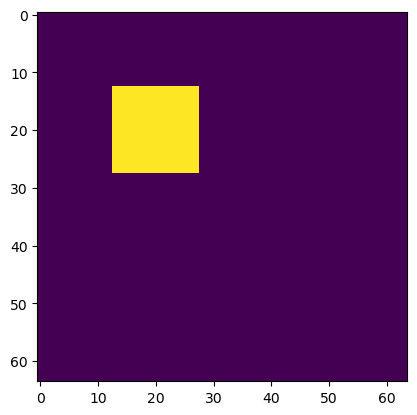

In [ ]:
# Your Work Here


# Plotting
plt.imshow(Volume.sample_mask)
plt.show()

With this sample map, we can assemble the final sample. Use `construct_sample` and `save_sample` to create and save the final sample file.

Let's now generate a brain sample. Please define 30x30x1 cm volume, at a resolution of 64x64x1.

As we are dealing with a more complex geometry, we will be importing a pre-exisiting sample map instead of creating one manually. For this tutorial we have provided a `.csv` file containing low-resolution segmented brain as an example, named `./NIBLEs/tutorial/June_2023_BrainMask.csv`. Please use NumPy's `loadtxt` function to import this file as an array.

**Note:** In general, if you are working with complex geometry beyond simple shapes, we recommend using segmented imaging data to create your sample. Be wary that sample generation is the most memory-intensive part of the NIBLEs package, and with high resolution imaging data it can be easy to exceed the memory capacity of a personal computer. We recommend a minimum of 16 GB of RAM for a computer used to generate samples, but depending on the size and resolution of your data 32+ GB is preferable. 

For our sample materials, instead of defining the materials manually we will be making uses of the library of materials built into NIBLEs `./NIBLEs/simCode/materials.py`. `materials.py` simply contains instances of the material class that are pre-filled with exisiting tissue parameters. As you make use of NIBLEs for your own work, we recommend adding the materials you create to `materials.py` for easy access. For this tutorial we have already imported `materials.py` as `matlib`, please create instances of the materials `WMSynth`, `GMSynth`, and `CSFSynth`. 

These materials contain two sets of relaxation time data: one set of constant relaxtion times at 3T, and a set of parameters for defining field dependent relaxation times. In general, these field-dependent parameters should be array of values used to calculate relaxation time using a specific function in `relaxfunc.py`. For the materials used in this tutorial, the dynamic field parameters are a 2xn array where the top row indicates applied field strength, and the bottom row contains measured relaxation times at each of the applied fields. This array is used by `relaxfunc.interpolation` to calculate relaxation times using interpolation between th given values (more on this in Part 4).

In [ ]:
# Define volume dimensions


# Define path to BrainMask.csv

# Load BrainMask.csv as a Numpy array

# Import material classes from materClasses.py


# Define number of vectors per voxel

# Sample name and path


With all relevant information defined, please create an instance of `ImagingVolume` named `Volume2`, and replace the automatically generated tissue map (`Volume2.sample_mask`) with the one we've loaded from file. We've included some plotting code below so you can see the tissue map.

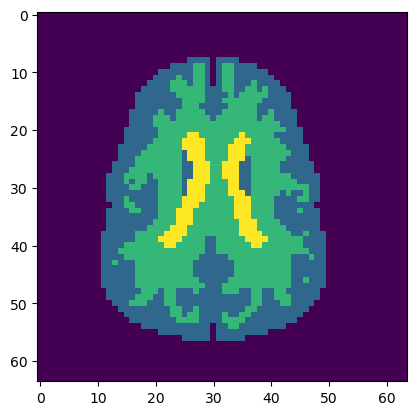

In [ ]:
# Your Work Here


# Plotting
plt.imshow(Volume2.sample_mask)
plt.show()

Once again, we can now use `construct_sample` and `save_sample` to create and save the final sample file. Please do so.

#### Congratulations, you have completed Part 3 of this tutorial. Please continue to Part 4, where we will use these samples to simulate MRI imaging experiments using NIBLEs!